In [4]:
!kaggle datasets download -d anthonytherrien/website-traffic
!unzip -o website-traffic.zip

Dataset URL: https://www.kaggle.com/datasets/anthonytherrien/website-traffic
License(s): CC-BY-SA-4.0
100% 63.7k/63.7k [00:00<00:00, 32.8MB/s]

Archive:  website-traffic.zip
  inflating: website_wata.csv        


In [7]:
import pandas as pd

df = pd.read_csv('website_wata.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(2000, 7)
['Page Views', 'Session Duration', 'Bounce Rate', 'Traffic Source', 'Time on Page', 'Previous Visits', 'Conversion Rate']


,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.051381,0.230652,Organic,3.890460,3,1.0
1,4,3.429316,0.391001,Social,8.478174,0,1.0
2,4,1.621052,0.397986,Organic,9.636170,2,1.0
3,5,3.629279,0.180458,Organic,2.071925,3,1.0
4,5,4.235843,0.291541,Paid,1.960654,5,1.0


In [6]:
!ls -la


total 35428
drwxr-xr-x 1 root root     4096 Jul 11 12:04 .
drwxr-xr-x 1 root root     4096 Jul 11 11:40 ..
drwxr-xr-x 4 root root     4096 Jun  4 13:32 .config
drwxr-xr-x 1 root root     4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root 30630222 Sep  1  2024 traffic.csv
-rw-r--r-- 1 root root  5409593 Sep  1  2024 website-traffic-analysis.zip
-rw-r--r-- 1 root root    65228 Aug  5  2024 website-traffic.zip
-rw-r--r-- 1 root root   149345 Aug  5  2024 website_wata.csv


In [11]:
print(df.info())
print("\n Misiing values: \n",df.isnull().sum())
print("\n Duplicates:",df.duplicated().sum())
print("\ Summary stats: \n",df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Page Views        2000 non-null   int64  
 1   Session Duration  2000 non-null   float64
 2   Bounce Rate       2000 non-null   float64
 3   Traffic Source    2000 non-null   object 
 4   Time on Page      2000 non-null   float64
 5   Previous Visits   2000 non-null   int64  
 6   Conversion Rate   2000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 109.5+ KB
None

 Misiing values: 
 Page Views          0
Session Duration    0
Bounce Rate         0
Traffic Source      0
Time on Page        0
Previous Visits     0
Conversion Rate     0
dtype: int64

 Duplicates: 0
\ Summary stats: 
         Page Views  Session Duration  Bounce Rate  Time on Page  \
count  2000.000000       2000.000000  2000.000000   2000.000000   
mean      4.950500          3.022045     0.284

<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_1875/2428173854.py:4: SyntaxWarning: invalid escape sequence '\ '
  print("\ Summary stats: \n",df.describe())


In [12]:
metrics_by_source = df.groupby('Traffic Source').agg(
    sessions=('Page Views', 'count'),
    avg_page_views=('Page Views', 'mean'),
    avg_session_duration=('Session Duration', 'mean'),
    avg_bounce_rate=('Bounce Rate', 'mean'),
    avg_time_on_page=('Time on Page', 'mean'),
    avg_conversion_rate=('Conversion Rate', 'mean'),
    avg_previous_visits=('Previous Visits', 'mean')
).round(3).sort_values('sessions', ascending=False)

print(metrics_by_source)

                sessions  avg_page_views  avg_session_duration  \
Traffic Source                                                   
Organic              786           5.025                 3.104   
Paid                 428           4.944                 2.943   
Referral             301           4.983                 3.125   
Social               269           4.695                 3.057   
Direct               216           4.963                 2.692   

                avg_bounce_rate  avg_time_on_page  avg_conversion_rate  \
Traffic Source                                                           
Organic                   0.282             3.978                0.982   
Paid                      0.296             4.087                0.979   
Referral                  0.266             3.985                0.988   
Social                    0.296             4.188                0.983   
Direct                    0.285             3.949                0.979   

                av

/tmp/ipykernel_1875/654596046.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_by_source.index, y=metrics_by_source['sessions'], ax=axes[0,0], palette='viridis')
/tmp/ipykernel_1875/654596046.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_by_source.index, y=metrics_by_source['avg_bounce_rate'], ax=axes[0,1], palette='rocket')
/tmp/ipykernel_1875/654596046.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_by_source.index, y=metrics_by_source['avg_conversion_rate'], ax=axes[1,1], palette='mako')


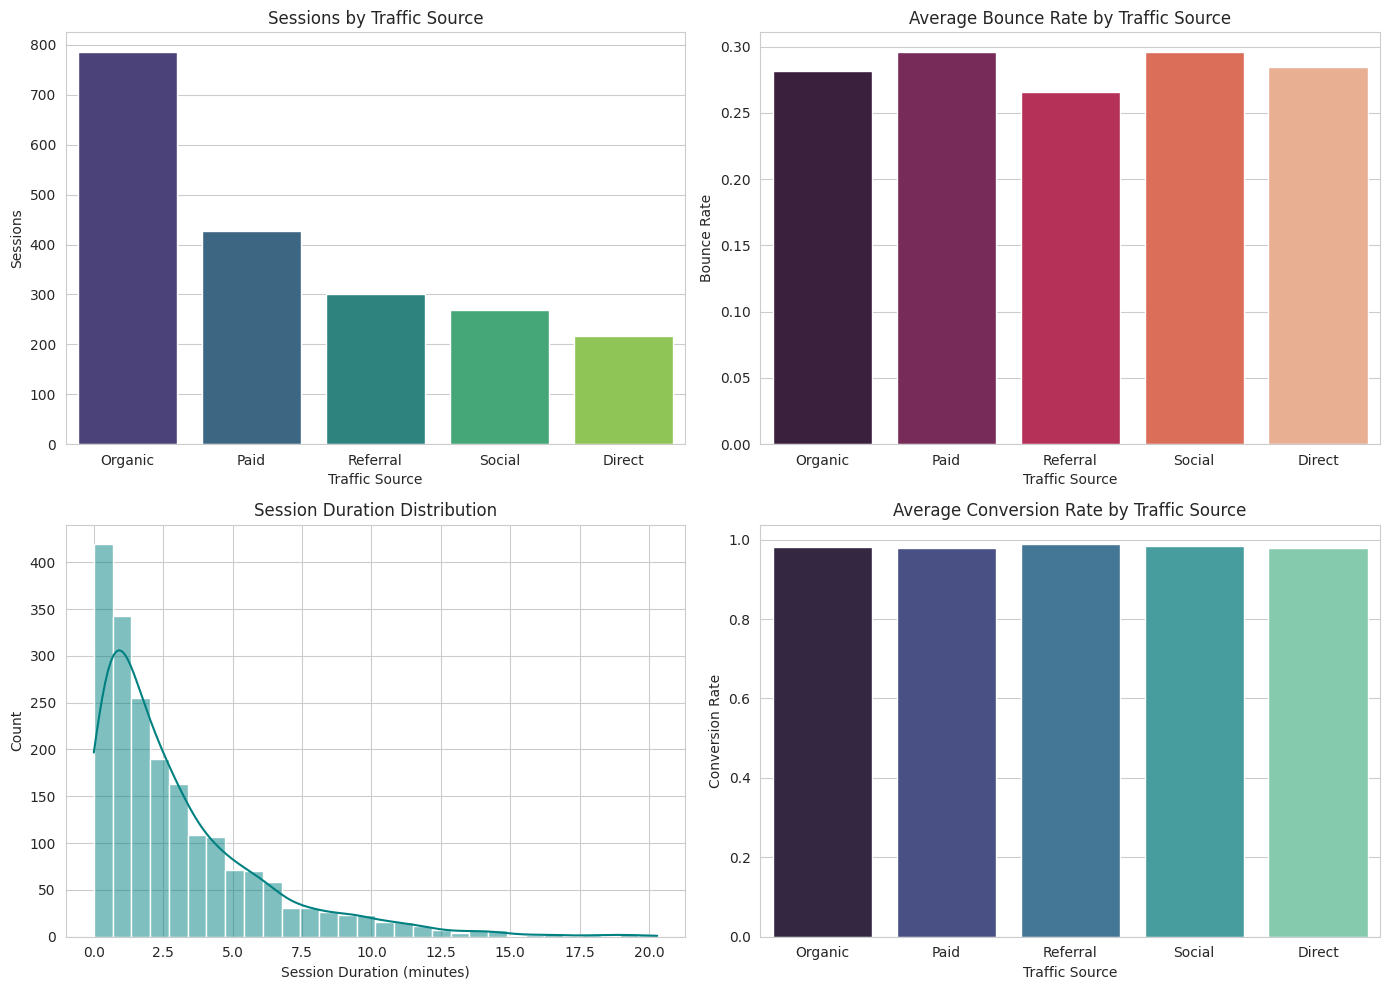

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(x=metrics_by_source.index, y=metrics_by_source['sessions'], ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Sessions by Traffic Source')
axes[0,0].set_ylabel('Sessions')
sns.barplot(x=metrics_by_source.index, y=metrics_by_source['avg_bounce_rate'], ax=axes[0,1], palette='rocket')
axes[0,1].set_title('Average Bounce Rate by Traffic Source')
axes[0,1].set_ylabel('Bounce Rate')
sns.histplot(df['Session Duration'], bins=30, kde=True, ax=axes[1,0], color='teal')
axes[1,0].set_title('Session Duration Distribution')
axes[1,0].set_xlabel('Session Duration (minutes)')
sns.barplot(x=metrics_by_source.index, y=metrics_by_source['avg_conversion_rate'], ax=axes[1,1], palette='mako')
axes[1,1].set_title('Average Conversion Rate by Traffic Source')
axes[1,1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.savefig('traffic_analysis_dashboard.png', dpi=150)
plt.show()

## Key Insights & Recommendations for Alfido Tech

**Insights:**
- Organic search is the dominant traffic channel (786 sessions, ~37% of total)
- Referral traffic has the lowest bounce rate (0.266) and highest conversion rate (0.988)
- Social traffic has the highest bounce rate (0.296) despite good time-on-page
- Most sessions last under 2.5 minutes, indicating a heavily front-loaded engagement pattern
- Direct visitors have the most previous visits, suggesting strong repeat/loyal user behavior

**5 Recommendations:**
1. Double down on Organic — invest in SEO/content to protect and grow the largest channel
2. Fix Social's high bounce rate — align ad/post messaging with landing page content
3. Learn from Referral's success — identify and strengthen top-performing partner sites
4. Reduce short-session drop-off — improve above-the-fold content and page load speed
5. Investigate Paid channel efficiency — review targeting and keywords to reduce bounce rate

In [14]:
!pip install reportlab -q

from reportlab.lib.pagesizes import A4
from reportlab.lib.units import inch
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle

styles = getSampleStyleSheet()
title_style = ParagraphStyle('TitleStyle', parent=styles['Title'], fontSize=20, spaceAfter=20)
heading_style = ParagraphStyle('HeadingStyle', parent=styles['Heading2'], spaceBefore=16, spaceAfter=8)
body_style = styles['BodyText']

doc = SimpleDocTemplate("Website_Traffic_Analysis_Report.pdf", pagesize=A4,
                        topMargin=0.6*inch, bottomMargin=0.6*inch)
elements = []

# Title
elements.append(Paragraph("Website Traffic Analysis Report", title_style))
elements.append(Paragraph("Prepared for Alfido Tech &mdash; OIBSIP Task 3", body_style))
elements.append(Spacer(1, 12))

# Goal
elements.append(Paragraph("Goal", heading_style))
elements.append(Paragraph(
    "Analyze website traffic data to understand user engagement, bounce rates, "
    "and traffic sources, and recommend optimizations to improve conversions for Alfido Tech.",
    body_style))

# Metrics table
elements.append(Paragraph("Metrics by Traffic Source", heading_style))
table_data = [["Source", "Sessions", "Avg Page Views", "Avg Session Duration",
               "Avg Bounce Rate", "Avg Conversion Rate"]]
for source, row in metrics_by_source.iterrows():
    table_data.append([
        source,
        int(row['sessions']),
        row['avg_page_views'],
        row['avg_session_duration'],
        row['avg_bounce_rate'],
        row['avg_conversion_rate']
    ])

t = Table(table_data, hAlign='LEFT')
t.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#2C3E50')),
    ('TEXTCOLOR', (0,0), (-1,0), colors.white),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE', (0,0), (-1,-1), 9),
    ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#F4F6F7')]),
    ('ALIGN', (1,0), (-1,-1), 'CENTER'),
    ('TOPPADDING', (0,0), (-1,-1), 6),
    ('BOTTOMPADDING', (0,0), (-1,-1), 6),
]))
elements.append(t)
elements.append(Spacer(1, 16))

# Dashboard image
elements.append(Paragraph("Visualizations", heading_style))
elements.append(Image("traffic_analysis_dashboard.png", width=6.5*inch, height=4.9*inch))
elements.append(Spacer(1, 16))

# Insights
elements.append(Paragraph("Key Insights", heading_style))
insights = [
    "Organic search is the dominant traffic channel (786 sessions, ~37% of total).",
    "Referral traffic has the lowest bounce rate (0.266) and highest conversion rate (0.988).",
    "Social traffic has the highest bounce rate (0.296) despite good time-on-page.",
    "Most sessions last under 2.5 minutes, indicating a heavily front-loaded engagement pattern.",
    "Direct visitors have the most previous visits, suggesting strong repeat/loyal user behavior.",
]
for i in insights:
    elements.append(Paragraph("&bull; " + i, body_style))
elements.append(Spacer(1, 12))

# Recommendations
elements.append(Paragraph("5 Recommendations for Alfido Tech", heading_style))
recommendations = [
    "Double down on Organic &mdash; invest in SEO/content to protect and grow the largest channel.",
    "Fix Social's high bounce rate &mdash; align ad/post messaging with landing page content.",
    "Learn from Referral's success &mdash; identify and strengthen top-performing partner sites.",
    "Reduce short-session drop-off &mdash; improve above-the-fold content and page load speed.",
    "Investigate Paid channel efficiency &mdash; review targeting and keywords to reduce bounce rate.",
]
for idx, r in enumerate(recommendations, 1):
    elements.append(Paragraph(f"{idx}. {r}", body_style))

doc.build(elements)
print("PDF report generated: Website_Traffic_Analysis_Report.pdf")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.5 MB/s eta 0:00:00
PDF report generated: Website_Traffic_Analysis_Report.pdf
